  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
[System] Seed=42 | Device=cuda
[System] Loss=weighted_ce | Scaler=quantile
EXPERIMENT M | Arch: KAN | Source: CICIDS2018 | Targets: ['ToN-IoT', 'UNSW-NB15']
[Data] Loading seyhed/nf-cicids2018-v3 ...
Using Colab cache for faster access to the 'nf-cicids2018-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 12.98%
PHASE 1: SOURCE PRE-TRAINING (CICIDS2018) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | CTTA-trainable params=20,610

   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[Pretrain] Epoch 1/20 | Loss: 0.1196 | Acc: 0.9886
[Pretrain] Epoch 2/20 | Loss: 0.1010 | Acc: 0.9910
[Pretrain] Epoch 3/20 | Loss: 0.0986 | Acc: 0.9912
[Pretrain] Epoch 4/20 | Loss: 0.0972 | Acc: 0.9912
[Pretrain] Epoch 5/20 | Loss: 0.0963 | Acc: 0.9914
[Pretrain] Epoch 6/20 | Loss: 0.0961 | Acc: 0.9914
[Pretrain] Epoch 7/20 | Loss:

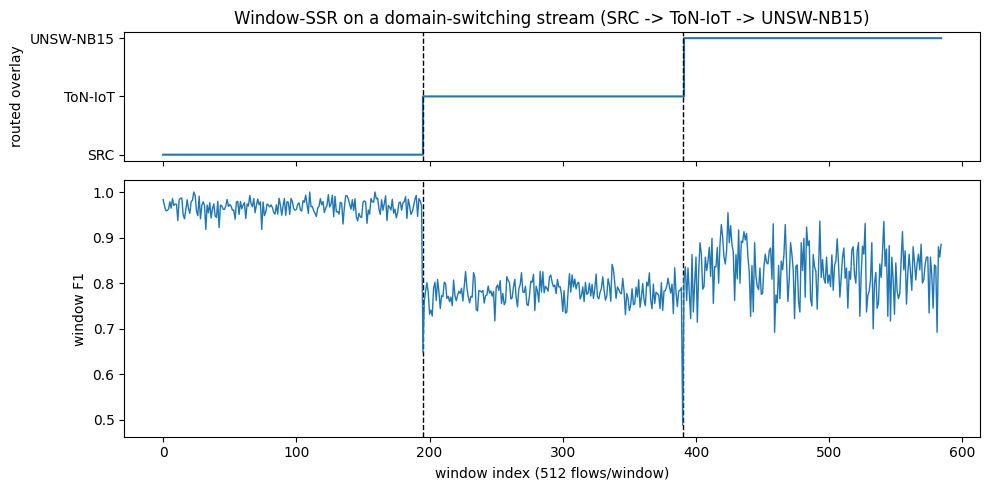

[wSSR] figure saved: fig_ssr_switch.png

[D v3] Done. Results in merge_results["ssr_window"].
[Joint] pool: 300 flows (100/domain), attack rate 19.0%

PART E — joint-pool fine-tune (300 labels) vs window-SSR (0 labels)
   [criterion] weighted CE | weights=[benign 0.62, attack 2.63]
[[Joint/selective] SRC] F1: 0.8666 | Acc: 0.9637
[[Joint/selective] ToN-IoT] F1: 0.7589 | Acc: 0.8269
[[Joint/selective] UNSW-NB15] F1: 0.6325 | Acc: 0.9683
   [criterion] weighted CE | weights=[benign 0.62, attack 2.63]
[[Joint/all params] SRC] F1: 0.8187 | Acc: 0.9535
[[Joint/all params] ToN-IoT] F1: 0.7601 | Acc: 0.8090
[[Joint/all params] UNSW-NB15] F1: 0.7823 | Acc: 0.9802

                 variant   f1_SRC  f1_ToN-IoT  f1_UNSW-NB15  f1_mean   f1_min
 joint pool (selective) 0.866550    0.758946      0.632505 0.752667 0.632505
joint pool (all params) 0.818674    0.760118      0.782336 0.787043 0.760118

[Reference] window-SSR this configuration: see Part D output (mean/min above). The joint baseline uses

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT M — WEIGHT-SPACE MODEL MERGING  (FULLY SELF-CONTAINED CELL)
#
# Paste this whole cell into a FRESH notebook/runtime and run it — it bundles
# every definition it needs from MahsaExpr10.ipynb (Sections 1-4: imports &
# config, scaling/losses/AGSA gate, data pipeline, models, training/CTTA),
# then runs the merging experiment. Nothing else from the notebook is needed.
#
#   Part A — post-hoc interpolation θ(α)=θ_src+α(θ_adapted−θ_src): a ZERO-DATA
#            retention dial (complements replay, Obs 8, which needs stored pools).
#   Part B — "fleet merge": adapt two copies of one source model to two targets
#            in parallel, merge into ONE model, evaluate on all three domains.
#   Part C — AGSA-routed merge (KAN-only): spline coefficients routed by which
#            domain ACTIVATED them; contested regions averaged; unvisited
#            regions provably stay at source.
# ═══════════════════════════════════════════════════════════════════════════


# ──────────────────────────────────────────────────────────────────────────
# BUNDLED FROM NOTEBOOK — (pip installs)
# ──────────────────────────────────────────────────────────────────────────
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
!pip install -q polars kagglehub

# ──────────────────────────────────────────────────────────────────────────
# BUNDLED FROM NOTEBOOK — Section 1: imports & configuration
# ──────────────────────────────────────────────────────────────────────────
import os, gc, random, datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import polars as pl
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
from efficient_kan import KAN
import pandas as pd
import matplotlib.pyplot as plt
# FIX: removed duplicate `import gc` (was imported twice)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = SEED):
    """FIX: single, complete seeding routine that can be re-invoked before each
    experiment config, so every (arch, source) run starts from an identical RNG
    state instead of inheriting whatever the previous run consumed."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False        # FIX: was never disabled

seed_everything(SEED)

def seeded_generator(seed: int = SEED) -> torch.Generator:
    """FIX: DataLoader shuffles were driven by the global RNG; give shuffling
    loaders their own seeded generator for run-to-run reproducibility."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g

############################ TO CHANGE ACROSS RUNS #############################
SPLINE_TRUE     = True

# ── Data ──────────────────────────────────────────────────────────────────────
SAMPLE_N        = 1_000_000
################################################################################
BATCH_SIZE      = 256
TTA_BATCH_SIZE  = 512        # larger batches = more stable gradient estimates

# ── Model ─────────────────────────────────────────────────────────────────────
LATENT_DIM      = 32

# ── Pre-training ──────────────────────────────────────────────────────────────
PRETRAIN_EPOCHS = 20
PRETRAIN_LR     = 1e-3
WEIGHT_DECAY    = 1e-4
RECON_W         = 0.5        # reconstruction regularises encoder for transfer

# ── CTTA ──────────────────────────────────────────────────────────────────────
FEW_SHOT_RATIO  = 0.0001     # fraction of target used as labelled pool
FEW_SHOT_MATCH_STEPS = False  # MOD: give the few-shot baseline the SAME number
                             # of optimizer steps as CTTA takes over the stream
                             # (previously 20 epochs = 20 steps vs CTTA's ~196
                             # — a hidden 10x step-budget advantage for CTTA in
                             # one direction and for few-shot in the other,
                             # depending on architecture). With matched steps,
                             # stream access is the ONLY difference.
AGSA_ABLATION   = True       # MOD: for KAN, rerun the headline CTTA mode with
                             # the spline gate OFF (same RNG/weights) and also
                             # record source-set F1 after adaptation — the two
                             # numbers that validate AGSA (no target cost +
                             # forgetting protection).
SCRATCH_BASELINE = True      # MOD: also run few-shot and CTTA from a RANDOM
                             # init (no source pretraining) with the same
                             # objectives and step budget, training ALL
                             # parameters — layer-selective updates on a
                             # random frozen encoder would be meaningless, so
                             # full-capacity training is the strongest honest
                             # form of this baseline. Quantifies the value of
                             # source pretraining.
MIN_POOL_SIZE   = 100        # MOD: hard floor so the pool never collapses
FEW_SHOT_W      = 1.0        # supervised CE weight during CTTA
TTA_LR          = 1e-2       # higher lr is fine — only norm params updated
TTA_STEPS       = 1
USE_ENTROPY     = True       # FIX(v1): term was silently commented out of the
                             # loss. FIX(v2): plain entropy min made CTTA worse
                             # — replaced by a robust variant (see
                             # stream_entropy_loss): confidence-filtered,
                             # confidence-weighted, and prior-anchored.
ENTROPY_W       = 1.0        # weight on the filtered entropy term
ENT_CONF_FRAC   = 0.4        # EATA-style reliability threshold: only samples
                             # with entropy < ENT_CONF_FRAC * ln(2) contribute
MARGINAL_W      = 1.0        # weight on KL(batch-mean prediction || pool
                             # prior) — anti-collapse anchor for imbalance
RECON_W_TTA     = 0.5        # reconstruction weight during CTTA
RECON_SOURCE    = 'stream'   # FIX: 'pool' recon (original) was redundant — it
                             # ran on the same ~100 samples CE already trains
                             # on every step, so it added no signal and no
                             # improvement. 'stream' turns it into TTT-style
                             # self-supervision on the unlabelled stream, where
                             # the shift actually is. Options:
                             #   'stream' | 'pool' | 'both' | 'none'
RESTORE_PROB    = 0.01       # MOD: stochastic restore (CoTTA) — after each
                             # update, each trainable weight snaps back to its
                             # source value with this probability. Bounds
                             # cumulative drift over long streams; the main
                             # defence against unsupervised collapse (the
                             # 'ent-only F1=0.01' failure). 0 disables.

# ── AGSA: Activation-Gated Spline Adaptation (NOVELTY, KAN-only) ──────────────
# KAN spline coefficients are LOCAL: each B-spline basis governs one region of
# an input's range. Coefficients of regions the target stream never visits get
# near-zero (pure-noise) gradients — but Adam's per-parameter normalisation
# amplifies them into full-size updates, silently corrupting the learned
# function exactly where the target provides no evidence. AGSA tracks which
# basis functions target data actually activates (EMA over stream + pool
# forwards) and hard-masks gradients for dormant coefficients: adaptation is
# confined to regions the target exercises, source knowledge elsewhere is
# structurally frozen. Architecture-intrinsic retention — no penalty term, no
# extra loss, no effect on visited-region fitting.
USE_SPLINE_GATE   = True
SPLINE_GATE_EMA   = 0.99     # EMA horizon for basis-activation mass
SPLINE_GATE_THRESH = 0.05    # coefficient is 'active' if its EMA mass exceeds
                             # this fraction of the max mass on that input dim
EWC_LAMBDA      = 0.0        # MOD/FIX: KAN_Retention (EWC) was computed but its
                             # penalty was NEVER added to the CTTA loss. Set > 0
                             # (e.g. 100.0) to actually apply retention.

# ── Loss (MOD: class imbalance) ───────────────────────────────────────────────
# 'ce'          : plain CrossEntropy (original behaviour)
# 'weighted_ce' : CrossEntropy with inverse-frequency class weights, computed
#                 from whatever labelled data trains each phase (source train
#                 split for pretraining, labelled pool for CTTA / few-shot)
# 'focal'       : Focal loss (Lin et al. 2017) with per-class alpha from the
#                 same inverse-frequency weights + focusing parameter gamma
LOSS_TYPE        = 'weighted_ce'
FOCAL_GAMMA      = 2.0
MAX_CLASS_WEIGHT = 20.0      # cap — a 100-sample pool with ~3 attacks would
                             # otherwise produce weights >16 and destabilise
                             # CTTA's already-high learning rate

# ── Scaling (MOD: transfer-friendly scaling) ──────────────────────────────────
# 'minmax'   : MinMaxScaler(-1, 1) + clip                (original behaviour)
# 'robust'   : median/IQR scaling; ±ROBUST_CLIP scaled units map to ±1, clip
# 'quantile' : rank-based QuantileTransformer -> uniform [-1, 1]. Immune to
#              heavy tails, and out-of-distribution target values saturate
#              gracefully at the grid boundary instead of a whole feature
#              collapsing when the source min/max doesn't cover target range
SCALER_TYPE = 'quantile'
ROBUST_CLIP = 4.0            # only used when SCALER_TYPE == 'robust'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[System] Seed={SEED} | Device={device}')
print(f'[System] Loss={LOSS_TYPE} | Scaler={SCALER_TYPE}')

# ──────────────────────────────────────────────────────────────────────────
# BUNDLED FROM NOTEBOOK — Section 1b: scaling, losses, stochastic restore, AGSA gate
# ──────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler, QuantileTransformer

class FeatureScaler:
    """
    MOD: pluggable scaling strategy behind the same fit/transform interface the
    rest of the pipeline already uses, so it drops in wherever a MinMaxScaler
    was passed around. Every mode guarantees float32 output in [-1, 1], which
    the KAN grid_range=[-1, 1] requires.

    'minmax'   — exactly the original behaviour (MinMax to [-1,1], then clip).
    'robust'   — (x - median) / IQR per feature; ±ROBUST_CLIP scaled units map
                 to ±1 and everything beyond clips. Outliers no longer define
                 the range, so the bulk of the data keeps its resolution.
    'quantile' — rank-based map to uniform [0,1] rescaled to [-1,1]. Fully
                 immune to heavy tails; out-of-range target values saturate at
                 the boundary instead of compressing the whole feature. This is
                 the transfer-friendliest option: when the source scaler is
                 reused on a shifted target, minmax can push a large share of a
                 feature onto the clip boundary, while quantile degrades softly.
    """
    def __init__(self, kind: str = SCALER_TYPE):
        if kind not in ('minmax', 'robust', 'quantile'):
            raise ValueError(f"Unknown SCALER_TYPE={kind!r}. "
                             f"Choose 'minmax', 'robust', or 'quantile'")
        self.kind = kind
        self._sk = None

    def fit(self, X):
        if self.kind == 'minmax':
            self._sk = MinMaxScaler(feature_range=(-1, 1)).fit(X)
        elif self.kind == 'robust':
            self._sk = RobustScaler(quantile_range=(5.0, 95.0)).fit(X)
        else:  # quantile
            self._sk = QuantileTransformer(
                output_distribution='uniform',
                n_quantiles=min(1000, len(X)),   # n_quantiles must be <= n_samples
                subsample=1_000_000,
                random_state=SEED,
            ).fit(X)
        return self

    def transform(self, X):
        if self._sk is None:
            raise RuntimeError('FeatureScaler.transform called before fit')
        Z = self._sk.transform(X)
        if self.kind == 'robust':
            Z = Z / ROBUST_CLIP                  # ±ROBUST_CLIP IQR-units -> ±1
        elif self.kind == 'quantile':
            Z = Z * 2.0 - 1.0                    # [0,1] -> [-1,1]
        return np.clip(Z, -1, 1).astype(np.float32)


def compute_class_weights(y) -> torch.Tensor:
    """
    MOD: inverse-frequency ('balanced') weights, w_c = N / (n_classes * N_c),
    capped at MAX_CLASS_WEIGHT. Accepts a numpy array or a torch tensor.
    Falls back to uniform weights if a class is absent (can happen in a tiny
    pool) so the criterion never divides by zero.
    """
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()
    y = np.asarray(y)
    counts = np.bincount(y, minlength=2).astype(np.float64)
    if (counts == 0).any():
        print('   [class weights] WARNING: a class is missing from the labelled '
              'data — falling back to uniform weights.')
        return torch.ones(2, dtype=torch.float32)
    w = len(y) / (2.0 * counts)
    w = np.minimum(w, MAX_CLASS_WEIGHT)
    return torch.tensor(w, dtype=torch.float32)


class FocalLoss(nn.Module):
    """
    MOD: Focal loss (Lin et al., 2017) for class-imbalanced classification.
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    alpha is a per-class weight tensor (here: the same inverse-frequency
    weights as 'weighted_ce'); gamma down-weights easy examples so training
    focuses on the hard minority. Reduces to alpha-weighted CE at gamma=0.
    """
    def __init__(self, alpha: torch.Tensor = None, gamma: float = FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma
        # registered as a buffer so .to(device) moves it with the module
        self.register_buffer('alpha',
                             alpha if alpha is not None else torch.ones(2))

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        log_pt    = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt        = log_pt.exp()
        alpha_t   = self.alpha.to(logits.device)[targets]
        loss      = -alpha_t * (1.0 - pt) ** self.gamma * log_pt
        return loss.mean()


def make_criterion(y, device) -> nn.Module:
    """
    MOD: build the classification criterion according to LOSS_TYPE, with class
    statistics taken from the labelled data actually used in that phase
    (source train split for pretraining; labelled pool for CTTA and the
    few-shot baseline). Centralised so every training path stays consistent.
    """
    if LOSS_TYPE == 'ce':
        return nn.CrossEntropyLoss()
    weights = compute_class_weights(y).to(device)
    if LOSS_TYPE == 'weighted_ce':
        print(f'   [criterion] weighted CE | weights='
              f'[benign {weights[0]:.2f}, attack {weights[1]:.2f}]')
        return nn.CrossEntropyLoss(weight=weights)
    if LOSS_TYPE == 'focal':
        print(f'   [criterion] focal (gamma={FOCAL_GAMMA}) | alpha='
              f'[benign {weights[0]:.2f}, attack {weights[1]:.2f}]')
        return FocalLoss(alpha=weights, gamma=FOCAL_GAMMA).to(device)
    raise ValueError(f"Unknown LOSS_TYPE={LOSS_TYPE!r}. "
                     f"Choose 'ce', 'weighted_ce', or 'focal'")


def labels_of(loader) -> torch.Tensor:
    """MOD: pull the label tensor back out of a TensorDataset-backed loader so
    criteria can be built from exactly the data a phase trains on."""
    return loader.dataset.tensors[1]


def reset_loader_generator(loader, seed: int = SEED):
    """
    FIX: shuffling DataLoaders carry their own dedicated torch.Generator,
    which torch.get_rng_state()/set_rng_state() do NOT cover — those only
    snapshot the global RNG. Every 'identical RNG' guarantee (dual-mode CTTA,
    few-shot isolation, ablation restore, AGSA on/off) therefore silently
    excluded pool shuffling. Re-seeding the loader's generator at the start of
    each comparable run makes every run see the identical shuffle sequence by
    construction, independent of what ran before it.
    """
    g = getattr(loader, 'generator', None)
    if g is not None:
        g.manual_seed(seed)


def reseed_loader(loader, seed: int = SEED):
    """FIX: shuffling DataLoaders carry a PRIVATE generator whose state
    advances across runs — torch.set_rng_state does NOT reset it. Without this,
    'matched-RNG' comparisons (spline vs full CTTA, AGSA on vs off, baselines)
    silently saw different pool orderings. Called at the start of every
    adaptation routine so each run consumes an identical shuffle sequence."""
    gen = getattr(loader, 'generator', None)
    if gen is not None:
        gen.manual_seed(seed)


def pool_prior(loader, device) -> torch.Tensor:
    """
    MOD: class prior estimated from the labelled pool. Because the pool is a
    stratified sample of the target, its attack rate is an unbiased estimate
    of the stream's — the one piece of distributional knowledge CTTA is
    legitimately allowed to use. Clamped away from 0 so the KL term below is
    always finite.
    """
    y = labels_of(loader).cpu().numpy()
    r = float(np.mean(y))
    prior = torch.tensor([1.0 - r, r], dtype=torch.float32, device=device)
    return prior.clamp_min(1e-3)


def stream_entropy_loss(logits_s, prior):
    """
    FIX: robust replacement for plain entropy minimisation, which degraded
    CTTA. Plain entropy min fails in two documented ways:

      (1) noisy gradients from unreliable samples — high-entropy predictions
          sit near the decision boundary, and pushing them to be confident in
          whatever direction they currently lean amplifies errors
          (Niu et al. 2022, EATA).
      (2) majority-class collapse — unconstrained confidence maximisation on
          an imbalanced stream is minimised by predicting 'benign' for
          everything, silently destroying attack recall.

    Remedies, applied together:
      - reliability filter: only samples with entropy below
        E0 = ENT_CONF_FRAC * ln(2) contribute (ln(2) = max binary entropy);
      - confidence weighting: contributions scaled by exp(E0 - e), so the
        most confident samples dominate (EATA's weighting);
      - prior anchor: KL(batch-mean prediction || pool prior) penalises drift
        of the predicted class ratio away from the pool's attack rate. This
        replaces SHOT-style marginal-entropy 'diversity', whose implicit
        balanced-classes assumption is wrong for NIDS (a 50/50 pull on a 3%%
        attack stream is itself a collapse pressure, just toward the middle).

    Returns a scalar loss (0 contribution from the entropy term if no sample
    passes the filter — the KL anchor is always active).
    """
    E0 = ENT_CONF_FRAC * float(np.log(2.0))
    log_probs = F.log_softmax(logits_s, dim=1)
    probs     = log_probs.exp()
    ent       = -(probs * log_probs).sum(dim=1)

    mask = ent < E0
    if mask.any():
        w = torch.exp(E0 - ent[mask]).detach()   # EATA weights — no grad through w
        loss_ent = (w * ent[mask]).sum() / w.sum()
    else:
        loss_ent = logits_s.new_zeros(())

    p_bar   = probs.mean(dim=0).clamp_min(1e-8)
    loss_kl = (p_bar * (p_bar / prior).log()).sum()

    return ENTROPY_W * loss_ent + MARGINAL_W * loss_kl


class StochasticRestore:
    """
    MOD: CoTTA-style stochastic restore (Wang et al. 2022). After each
    optimizer step, every element of every trainable tensor is reset to its
    source (post-pretrain) value with probability RESTORE_PROB.

    Why: over a ~1M-sample stream (~2000 updates) small per-step errors
    compound — the dominant failure of unsupervised objectives (the entropy-
    only 'F1 = 0.01' collapse), and a latent risk even for anchored CTTA.
    Stochastic restore makes total drift mean-reverting toward the source
    weights without freezing anything, and unlike a hard periodic reset it
    never discards adaptation wholesale. Applied identically to every config
    (headline run + all ablation rows) so comparability is preserved.
    """
    def __init__(self, params, prob: float = RESTORE_PROB):
        self.prob   = float(prob)
        self.params = list(params)
        self.source = [p.data.clone() for p in self.params]

    @torch.no_grad()
    def __call__(self):
        if self.prob <= 0:
            return
        for p, s in zip(self.params, self.source):
            mask = torch.rand_like(p) < self.prob
            p.data[mask] = s[mask]


class SplineActivationGate:
    """
    NOVELTY — Activation-Gated Spline Adaptation (AGSA). KAN-specific TTA.

    Mechanism:
      * a forward pre-hook on a KANLinear layer captures its input on every
        forward pass — including the label-free predict pass, so the
        activation statistics come for free, with zero extra compute;
      * the layer's own b_splines() gives per-(input-dim, coefficient) basis
        activation; an EMA accumulates this 'visitation mass' over the stream;
      * a gradient hook on spline_weight zero-masks coefficients whose mass is
        below SPLINE_GATE_THRESH of the per-dim maximum.

    Why it can't hurt visited regions: for active coefficients the gradient is
    passed through unchanged. Why it protects the rest: dormant coefficients
    receive only basis-tail noise, which Adam would renormalise into full-size
    updates — the gate cuts that path entirely, so the function outside the
    target's support stays exactly at its source shape (retention by
    architecture rather than by penalty; complements or replaces EWC).

    Warm-up: until the first mass estimate exists, gradients pass ungated.
    Call remove() when done; coverage() reports the adapted fraction and
    mask() can be visualised as an adapted-vs-frozen heatmap per input dim.
    """
    def __init__(self, layer, ema: float = SPLINE_GATE_EMA,
                 thresh: float = SPLINE_GATE_THRESH):
        if not (hasattr(layer, 'b_splines') and hasattr(layer, 'spline_weight')):
            raise ValueError('SplineActivationGate needs an efficient-kan '
                             'KANLinear-style layer (b_splines + spline_weight).')
        self.layer  = layer
        self.ema    = float(ema)
        self.thresh = float(thresh)
        self.mass   = None      # (in_features, n_coeff) EMA of |basis|
        # NOVELTY (cumulative AGSA): coefficients owned by previously-adapted
        # domains. None until freeze_current() is called; once set, these
        # coefficients receive zero gradient in all later stages, partitioning
        # the spline support across a domain sequence.
        self.protected = None
        # capture switch: external (cumulative) gates stay attached across a
        # whole domain sequence, including evaluation passes on OTHER domains;
        # capture is enabled only while the current adaptation stage runs so
        # the mass reflects the current domain, not the evaluation traffic.
        self.capture = True
        self._h_in   = layer.register_forward_pre_hook(self._capture)
        self._h_grad = layer.spline_weight.register_hook(self._gate)

    def _capture(self, module, inputs):
        if not self.capture:
            return
        x = inputs[0]
        if x.dim() != 2:                      # defensive: expect (batch, in)
            return
        with torch.no_grad():
            b = module.b_splines(x.detach()).abs().mean(dim=0)  # (in, n_coeff)
            self.mass = b if self.mass is None \
                        else self.ema * self.mass + (1.0 - self.ema) * b

    def mask(self):
        if self.mass is None:
            return None
        ref = self.mass.max(dim=-1, keepdim=True).values.clamp_min(1e-12)
        return (self.mass > self.thresh * ref).to(self.layer.spline_weight.dtype)

    def _gate(self, grad):
        m = self.mask()
        allow = m                              # activation-localised updates
        if self.protected is not None:
            # NOVELTY (cumulative AGSA): zero gradient on coefficients owned
            # by earlier domains in the sequence, regardless of whether the
            # current domain also activates them.
            keep = (~self.protected).to(grad.dtype)
            allow = keep if allow is None else allow * keep
        if allow is None:
            return grad                        # warm-up: ungated
        # spline_weight: (out, in, n_coeff); allow: (in, n_coeff) — broadcast
        return grad * allow.unsqueeze(0)

    def freeze_current(self) -> float:
        """
        NOVELTY (cumulative AGSA): call at the END of a domain's adaptation
        stage. Folds the current domain's activation mask into the protected
        set (union) and resets the mass EMA so the next stage measures the
        next domain's activations from scratch. Returns the protected
        fraction — the share of spline coefficients now owned by past domains.

        NOTE: exact freezing of protected coefficients requires a FRESH
        optimizer for the next stage — a reused Adam would keep moving them
        via leftover momentum despite zero gradients (the same per-parameter
        pathology AGSA targets). run_ctta constructs a new optimizer on every
        call, so the sequential protocol satisfies this by construction.
        """
        m = self.mask()
        if m is not None:
            mb = m.bool()
            self.protected = mb if self.protected is None else (self.protected | mb)
        self.mass = None
        return 0.0 if self.protected is None else float(self.protected.float().mean())

    def coverage(self) -> float:
        m = self.mask()
        return float('nan') if m is None else float(m.mean())

    def remove(self):
        self._h_in.remove()
        self._h_grad.remove()

# ──────────────────────────────────────────────────────────────────────────
# BUNDLED FROM NOTEBOOK — Data pipeline: features, loading, loaders
# ──────────────────────────────────────────────────────────────────────────
def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    """Derive flow-level features and drop identifier/label columns."""
    if 'FLOW_END_MILLISECONDS' in df.columns and 'FLOW_START_MILLISECONDS' in df.columns:
        df = df.with_columns(
            # FIX: clip at 0 — corrupted flows with end < start produced negative
            # durations, and log1p(x < -1) = NaN downstream.
            (pl.col('FLOW_END_MILLISECONDS') - pl.col('FLOW_START_MILLISECONDS'))
            .clip(lower_bound=0).alias('FLOW_DURATION')
        )
    else:
        df = df.with_columns(pl.lit(0).alias('FLOW_DURATION'))
    if 'IN_BYTES' in df.columns and 'IN_PKTS' in df.columns:
        df = df.with_columns(
            (pl.col('IN_BYTES') / (pl.col('IN_PKTS') + 1e-5)).alias('BYTES_PER_PKT')
        )
    # FIX: BYTES_PER_PKT was created but never log-transformed although it is as
    # heavy-tailed as the columns it is derived from. Also clip all log inputs
    # at 0 to guarantee log1p never sees values < -1.
    log_cols = ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION', 'BYTES_PER_PKT',
                'SRC_TO_DST_IAT_MAX', 'DST_TO_SRC_IAT_MAX']
    existing = [c for c in log_cols if c in df.columns]
    if existing:
        df = df.with_columns([pl.col(c).clip(lower_bound=0).log1p() for c in existing])
    drop_cols = [
        'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
        'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT',
        'Label', 'Attack', 'label', 'attack', 'Date',
    ]
    df = df.drop([c for c in drop_cols if c in df.columns])
    # FIX: keep only numeric columns. The original called .to_numpy().astype
    # (float32) on whatever remained — any stray string/categorical column in a
    # dataset variant crashed the run (or worse, silently produced garbage).
    numeric = [c for c, dt in zip(df.columns, df.dtypes) if dt.is_numeric()]
    dropped = [c for c in df.columns if c not in numeric]
    if dropped:
        print(f'   [engineer_features] Dropping non-numeric columns: {dropped}')
    return df.select(numeric)


def align_features(df: pl.DataFrame, reference_features: list) -> pl.DataFrame:
    """FIX (critical): the original code assumed source and target datasets had
    identical feature columns in identical ORDER. `scaler.transform` and the
    model consume a bare NumPy matrix, so any order mismatch silently fed
    feature i of the target into the slot learned for feature j of the source.
    This reindexes the target to the source schema: shared columns are
    reordered, missing ones are zero-filled (with a warning), extras dropped."""
    missing = [c for c in reference_features if c not in df.columns]
    extra   = [c for c in df.columns if c not in reference_features]
    if missing:
        print(f'   [align_features] WARNING: target missing {len(missing)} source '
              f'features (zero-filled): {missing}')
        df = df.with_columns([pl.lit(0.0, dtype=pl.Float32).alias(c) for c in missing])
    if extra:
        print(f'   [align_features] Dropping {len(extra)} target-only features: {extra}')
    return df.select(reference_features)


def load_dataset(dataset_name: str, sample_n: int = None, align_to: list = None):
    """Download dataset and return (X, y, feature_names). Uses random sampling.

    FIX: the original read only csv_files[0] — an arbitrary file from os.walk —
    and silently ignored every other CSV in multi-file datasets. All CSVs are
    now concatenated (vertical_relaxed handles dtype drift between files).
    """
    print(f'[Data] Loading {dataset_name} ...')
    path = kagglehub.dataset_download(dataset_name)
    csv_files = sorted(
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    )
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found under {path}')
    frames = [pl.scan_csv(f) for f in csv_files]
    df = pl.concat(frames, how='vertical_relaxed').collect(engine='streaming')
    if sample_n and sample_n < df.height:
        df = df.sample(n=sample_n, seed=SEED)
    label_col = next((c for c in df.columns if c.lower() == 'label'), None)
    # FIX: warn instead of silently fabricating an all-benign label vector.
    if label_col is None:
        print("   WARNING: no 'label' column found — y set to all zeros; "
              "F1 on this dataset is meaningless.")
        y = np.zeros(df.height, dtype=np.int64)
    else:
        y = df[label_col].to_numpy().astype(np.int64)
    df = engineer_features(df)
    if align_to is not None:
        df = align_features(df, align_to)          # FIX: schema alignment
    feature_names = df.columns
    X = df.to_numpy().astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'   -> Shape: {X.shape} | Attack rate: {np.mean(y):.2%}')
    return X, y, feature_names


def make_source_loaders(X, y):
    """
    Stratified 80/20 split. Scaler fitted on the training split only.
    Training loader contains all labelled samples (benign + attack).
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    # MOD: pluggable scaling strategy (SCALER_TYPE). FeatureScaler.transform
    # already returns float32 clipped to [-1, 1] in every mode.
    scaler = FeatureScaler(SCALER_TYPE).fit(X_tr)
    X_tr   = scaler.transform(X_tr)
    X_te   = scaler.transform(X_te)
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    loader_tr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           generator=seeded_generator())      # FIX: seeded shuffle
    loader_te = DataLoader(test_ds,  batch_size=TTA_BATCH_SIZE, shuffle=False)
    return loader_tr, loader_te, scaler


def make_target_loaders(X, y, external_scaler=None):
    """
    Split the target into a small labelled pool and an unlabelled-at-adaptation
    stream (labels kept for evaluation only).

    FIX (docstring): the original docstring claimed 'Fit a fresh MinMaxScaler on
    the full target dataset' but the code (a) fitted on the pool only, and (b)
    was always called with the SOURCE scaler anyway. The behaviour is now stated
    honestly: if external_scaler is given it is used (deployment-realistic — no
    target statistics assumed); otherwise a scaler is fitted on the pool only,
    which is the only data an analyst would have labelled/inspected.

    The pool represents a brief initial analyst review period at deployment.
    """
    # FIX: with FEW_SHOT_RATIO=1e-4 the pool size depends entirely on SAMPLE_N
    # and can drop below the point where stratification is even possible
    # (train_test_split raises if the minority class has < 2 members, and the
    # 'both classes preserved' claim in the old comment was not guaranteed).
    pool_n = max(int(round(len(y) * FEW_SHOT_RATIO)), MIN_POOL_SIZE)
    X_pool, X_stream, y_pool, y_stream = train_test_split(
        X, y,
        train_size=pool_n,
        random_state=SEED,
        stratify=y,
    )
    if y_pool.sum() < 2:
        print(f'   WARNING: pool contains only {int(y_pool.sum())} attack '
              f'sample(s); supervised anchoring will be very weak.')

    # MOD: pluggable scaling strategy (SCALER_TYPE) via FeatureScaler.
    scaler   = external_scaler if external_scaler is not None \
               else FeatureScaler(SCALER_TYPE).fit(X_pool)

    X_pool   = scaler.transform(X_pool)
    X_stream = scaler.transform(X_stream)

    pool_ds   = TensorDataset(torch.from_numpy(X_pool),   torch.from_numpy(y_pool))
    stream_ds = TensorDataset(torch.from_numpy(X_stream), torch.from_numpy(y_stream))

    pool_loader   = DataLoader(pool_ds, batch_size=BATCH_SIZE, shuffle=True,
                               generator=seeded_generator())   # FIX: seeded shuffle
    stream_loader = DataLoader(stream_ds, batch_size=TTA_BATCH_SIZE, shuffle=False)

    print(f'   -> Pool: {len(y_pool)} samples '
          f'(attack rate: {np.mean(y_pool):.2%}) | '
          f'Stream: {len(y_stream)} '
          f'(attack rate: {np.mean(y_stream):.2%})')
    return pool_loader, stream_loader

# ──────────────────────────────────────────────────────────────────────────
# BUNDLED FROM NOTEBOOK — Section 2: models
# ──────────────────────────────────────────────────────────────────────────
class KanAEClassifier(nn.Module):
    """
    Shared KAN encoder → classifier head + decoder head.

    Encoder:    input_dim -> 64 -> latent_dim  (KAN)
    Classifier: latent_dim -> 2                (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (KAN)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder    = KAN([input_dim, 64, latent_dim], grid_range=[-1, 1])
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder    = KAN([latent_dim, 64, input_dim], grid_range=[-1, 1])

    def forward(self, x):
        z = self.ln(self.encoder(x))
        return self.classifier(z), self.decoder(z), z


class TabTransformerAEClassifier(nn.Module):
    """
    Shared TabTransformer encoder → classifier head + decoder head.
    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32,
                 n_heads: int = 4, d_token: int = 16):
        super().__init__()
        self.input_dim = input_dim
        self.d_token   = d_token
        self.feature_proj = nn.Linear(1, d_token, bias=False)
        self.feature_bias = nn.Parameter(torch.randn(input_dim, d_token) * 0.02)
        self.ln1 = nn.LayerNorm(d_token)
        self.attn = nn.MultiheadAttention(d_token, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * 4), nn.GELU(),
            nn.Linear(d_token * 4, d_token),
        )
        self.encoder_out = nn.Linear(d_token, latent_dim)
        self.ln          = nn.LayerNorm(latent_dim)
        self.classifier  = nn.Linear(latent_dim, 2)
        self.decoder     = nn.Sequential(
            nn.Linear(latent_dim, d_token),
            nn.LayerNorm(d_token), nn.GELU(),
            nn.Linear(d_token, input_dim),
        )

    def forward(self, x):
        tokens = self.feature_proj(x.unsqueeze(-1)) + self.feature_bias.unsqueeze(0)
        tokens = self.ln1(tokens)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = tokens + attn_out
        tokens = self.ln2(tokens)
        tokens = tokens + self.ffn(tokens)
        pooled = tokens.mean(dim=1)
        z = self.ln(self.encoder_out(pooled))
        return self.classifier(z), self.decoder(z), z


class CnnAEClassifier(nn.Module):
    """
    Shared CNN encoder → classifier head + decoder head.

    NOTE (design, unchanged): Conv1d with kernel_size=1 over a length-1
    sequence is mathematically identical to a Linear layer — the 'CNN' baseline
    is really an MLP with GroupNorm. Kept as-is for continuity with prior runs,
    but be aware of this when describing it in a paper.
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.Conv1d(64, latent_dim, kernel_size=1),
        )
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.ConvTranspose1d(64, input_dim, kernel_size=1),
        )

    def forward(self, x):
        z     = self.ln(self.encoder(x.unsqueeze(-1)).squeeze(-1))
        recon = self.decoder(z.unsqueeze(-1)).squeeze(-1)
        return self.classifier(z), recon, z


def build_model(arch: str, input_dim: int) -> nn.Module:
    if arch == 'kan':
        return KanAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'cnn':
        return CnnAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'tab':
        return TabTransformerAEClassifier(input_dim, LATENT_DIM)
    else:
        raise ValueError(f"Unknown ARCH={arch!r}. Choose 'kan', 'cnn', or 'tab'")


def get_trainable_params(model: nn.Module):
    """
    Return parameters for layer-selective CTTA updates.

    Updated: all LayerNorm/GroupNorm params (outside decoder), classifier head,
    last encoder layer. Frozen: early encoder layers, decoder.
    """
    params = []
    seen   = set()

    def add(p):
        if id(p) not in seen:
            seen.add(id(p))
            params.append(p)

    for name, module in model.named_modules():
        if 'decoder' in name:
            continue
        if isinstance(module, (nn.LayerNorm, nn.GroupNorm)):
            for p in module.parameters():
                add(p)

    for p in model.classifier.parameters():
        add(p)

    if isinstance(model, KanAEClassifier):
        if hasattr(model.encoder, 'layers') and len(model.encoder.layers) > 0:
            for p in model.encoder.layers[-1].parameters():
                add(p)
    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            for p in last_layer.parameters():
                add(p)
    elif isinstance(model, TabTransformerAEClassifier):
        for p in model.encoder_out.parameters():
            add(p)

    return params

# ──────────────────────────────────────────────────────────────────────────
# BUNDLED FROM NOTEBOOK — Section 4: training / evaluation / CTTA
# ──────────────────────────────────────────────────────────────────────────
def pretrain_source(model, loader, epochs, device):
    """
    Joint supervised + reconstruction pre-training.
    Loss = CrossEntropy(logits, y) + RECON_W * MSE(recon, x)
    """
    optimizer = optim.Adam(model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)
    # MOD: imbalance-aware criterion (LOSS_TYPE) built from the labels of the
    # source training split — the exact data this phase trains on.
    ce_crit   = make_criterion(labels_of(loader), device)
    mse_crit  = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss, correct, total, n_batches = 0.0, 0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, recon, _ = model(x)
            loss = ce_crit(logits, y) + RECON_W * mse_crit(recon, x)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                # FIX: a single NaN batch used to be added to total_loss,
                # turning the reported epoch loss into NaN permanently.
                total_loss += loss.item()
                n_batches  += 1
            correct += (logits.argmax(1) == y).sum().item()
            total   += y.size(0)
        print(f'[Pretrain] Epoch {epoch+1}/{epochs} | '
              f'Loss: {total_loss/max(n_batches,1):.4f} | '
              f'Acc: {correct/total:.4f}')


def evaluate(model, loader, device, desc='Eval'):
    """Evaluate using classifier head — argmax of logits."""
    was_training = model.training      # FIX: restore mode instead of leaving eval
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    if was_training:
        model.train()
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    f1  = f1_score(labels, preds, zero_division=0)
    acc = accuracy_score(labels, preds)
    print(f'[{desc}] F1: {f1:.4f} | Acc: {acc:.4f}')
    return f1


def get_spline_only_params(model):
    """
    Minimal-parameter trainable set for CTTA, per architecture.
    KAN: only spline_weight (+ spline_scaler) of the last encoder layer.
    CNN/Tab: last encoder projection ('last-layer-only' semantics).
    """
    params = []

    if isinstance(model, KanAEClassifier):
        if not hasattr(model.encoder, 'layers') or len(model.encoder.layers) == 0:
            return []
        last = model.encoder.layers[-1]
        if hasattr(last, 'spline_weight') and isinstance(last.spline_weight, torch.nn.Parameter):
            params.append(last.spline_weight)
        if hasattr(last, 'spline_scaler') and isinstance(last.spline_scaler, torch.nn.Parameter):
            params.append(last.spline_scaler)

    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            params.extend(last_layer.parameters())

    elif isinstance(model, TabTransformerAEClassifier):
        params.extend(model.encoder_out.parameters())

    return params


def run_ctta(model, stream_loader, pool_loader, device, spline_only=False,
             ewc=None, ewc_lambda=0.0, spline_gate=None,
             train_all=False, restore_prob=None,
             prior=None, external_gates=None):
    """
    Few-Shot Layer-Selective CTTA.

    Evaluation protocol — PREDICT-THEN-ADAPT (MOD): each incoming stream batch
    is first predicted with the current model (adapted on all *previous*
    batches only), and only then used for adaptation. This is the standard
    online TTA protocol (TENT et al.): reported F1 is the performance a
    deployed system would actually have delivered, and the model never gets a
    transductive peek at the batch it is being scored on.

    Per stream batch:
      0. Predict with the current model — these predictions are what's scored
      1. Supervised CE on pool batch — anchors decision boundary to target
      2. (USE_ENTROPY) robust entropy objective on the stream batch —
         confidence-filtered + confidence-weighted entropy, plus a
         KL(batch marginal || pool prior) anti-collapse anchor.
      3. Reconstruction (RECON_SOURCE) — FIX: default moved from pool to
         stream. Pool recon ran on the same ~100 samples CE already fits every
         step (redundant — observed to give no improvement); stream recon is
         TTT-style self-supervision on the unlabelled shifted data, matching
         the pretraining objective (which reconstructed all samples).
      4. (ewc_lambda>0) EWC retention penalty toward source weights
      5. Stochastic restore (RESTORE_PROB) — MOD: CoTTA-style anti-drift;
         see StochasticRestore.

    Returns (preds, labels, trajectory) on the stream.
    """
    if train_all:
        # MOD: scratch-baseline mode — every parameter trains (a random frozen
        # encoder under layer-selective updates would be meaningless).
        train_params = list(model.parameters())
        print('[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).')
    elif spline_only:
        train_params = get_spline_only_params(model)
        print('[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.')
    else:
        train_params = get_trainable_params(model)

    # FIX: guard — Adam raises an opaque error on an empty parameter list
    # (possible if a KAN build lacks the expected spline attributes).
    if len(train_params) == 0:
        raise RuntimeError('run_ctta: no trainable parameters were selected — '
                           'check get_spline_only_params for this architecture.')

    trainable_ids = {id(p) for p in train_params}
    for p in model.parameters():
        p.requires_grad = (id(p) in trainable_ids)

    print(f'[CTTA] Updating {len(train_params)} param tensors '
          f'({sum(p.numel() for p in train_params)} params). '
          f'All other weights frozen.')

    optimizer = optim.Adam(train_params, lr=TTA_LR)
    # MOD: imbalance-aware criterion (LOSS_TYPE) built from the labelled pool —
    # the only labelled target data CTTA is allowed to see. With a replay pool
    # (sequential setting) this correctly weights the union of domains' labels.
    ce_crit   = make_criterion(labels_of(pool_loader), device)
    # MOD: class prior for the anti-collapse anchor. Defaults to the pool's
    # rate; a caller using a REPLAY pool must pass the CURRENT domain's prior
    # explicitly — mixing past domains' attack rates into the anchor would
    # pull the stream's predicted ratio toward the wrong value.
    if USE_ENTROPY:
        prior = pool_prior(pool_loader, device) if prior is None else prior.to(device)
    else:
        prior = None
    # MOD: CoTTA-style stochastic restore toward the model's INITIAL weights.
    # restore_prob=None uses the global RESTORE_PROB; the scratch baseline
    # passes 0 — pulling back toward a random init would fight learning and
    # unfairly handicap the baseline.
    restore   = StochasticRestore(train_params,
                                  RESTORE_PROB if restore_prob is None else restore_prob)
    # NOVELTY (AGSA): gate spline gradients by target basis activation.
    # Attached to every KAN encoder layer that is actually being trained.
    # spline_gate=None follows the global USE_SPLINE_GATE; True/False overrides
    # (used by the AGSA on/off ablation).
    use_gate = USE_SPLINE_GATE if spline_gate is None else spline_gate
    manage_gates = external_gates is None    # NOVELTY (cumulative AGSA): a
    # caller may pass pre-attached gates whose state (activation mass +
    # protected masks) persists ACROSS run_ctta calls — the sequential
    # experiment uses this to accumulate domain ownership. run_ctta then
    # neither constructs nor removes them; the caller owns their lifecycle.
    gates = []
    if not manage_gates:
        gates = list(external_gates)
        for g in gates:
            g.capture = True     # FIX: record activations only during this
                                 # stage — between-stage evaluation passes on
                                 # other domains must not pollute the mass.
        if gates:
            print(f'[CTTA] AGSA (external/cumulative) active on {len(gates)} '
                  f'KAN layer(s); gate state persists across stages.')
    elif use_gate and isinstance(model, KanAEClassifier):
        for layer in model.encoder.layers:
            if any(id(p) in trainable_ids for p in layer.parameters()):
                try:
                    gates.append(SplineActivationGate(layer))
                except ValueError:
                    pass
        if gates:
            print(f'[CTTA] AGSA active on {len(gates)} KAN layer(s): spline '
                  f'updates confined to target-activated basis regions.')
    model.train()

    # FIX: reset the pool loader's private shuffle generator so every CTTA run
    # sees the identical pool batch sequence regardless of prior runs (see
    # reset_loader_generator — global RNG snapshots do not cover this).
    reset_loader_generator(pool_loader)
    pool_iter = iter(pool_loader)
    def next_pool():
        nonlocal pool_iter
        try:
            return next(pool_iter)
        except StopIteration:
            pool_iter = iter(pool_loader)
            return next(pool_iter)

    all_preds, all_labels = [], []
    trajectory = []
    batch_count = 0
    TRAJ_INTERVAL = 20

    try:                       # FIX: hooks must be removed even on exception —
        # otherwise a failed run leaks gates onto the model and the next run
        # double-gates gradients and double-counts activation statistics.
        for x_stream, y_stream in stream_loader:
            x_stream = x_stream.to(device)

            # ── 0. Predict FIRST with the current model (MOD: was after the
            #       adaptation step — an adapt-then-predict protocol that both
            #       inflated streaming numbers and, with entropy on, let the model
            #       train on the very batch it was about to be scored on).
            with torch.no_grad():
                model.eval()
                logits_f, _, _ = model(x_stream)
                preds = logits_f.argmax(1).cpu().numpy()
                model.train()

            all_preds.extend(preds)
            all_labels.extend(y_stream.numpy())

            # ── Adapt on this batch (affects future batches only) ─────────────
            for _ in range(TTA_STEPS):
                optimizer.zero_grad()

                # ── 1. Supervised CE on pool batch ────────────────────────────
                x_pool, y_pool = next_pool()
                x_pool = x_pool.to(device)
                y_pool = y_pool.to(device)
                logits_pool, recon_pool, _ = model(x_pool)
                loss_ce = ce_crit(logits_pool, y_pool)

                loss = FEW_SHOT_W * loss_ce

                # ── 2+3a. Stream forward: entropy and/or stream reconstruction ─
                # (one shared forward pass — recon on the stream is free when the
                # entropy term already needs the logits, and vice versa)
                if USE_ENTROPY or RECON_SOURCE in ('stream', 'both'):
                    logits_s, recon_s, _ = model(x_stream)
                    if USE_ENTROPY:
                        loss = loss + stream_entropy_loss(logits_s, prior)
                    if RECON_SOURCE in ('stream', 'both'):
                        # all stream samples, matching the pretraining recon target
                        loss = loss + RECON_W_TTA * F.mse_loss(recon_s, x_stream)

                # ── 3b. Reconstruction on benign pool samples (legacy option) ──
                if RECON_SOURCE in ('pool', 'both'):
                    benign_mask = (y_pool == 0)
                    if benign_mask.any():
                        loss_recon = F.mse_loss(recon_pool[benign_mask], x_pool[benign_mask])
                        loss = loss + RECON_W_TTA * loss_recon

                # ── 4. EWC retention penalty (optional) ───────────────────────
                if ewc is not None and ewc_lambda > 0:
                    loss = loss + ewc_lambda * ewc.penalty()

                if not (torch.isnan(loss) or torch.isinf(loss)):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                    optimizer.step()
                    restore()   # MOD: stochastic restore after each update

            batch_count += 1
            if batch_count % TRAJ_INTERVAL == 0:
                trajectory.append((batch_count,
                                   f1_score(all_labels, all_preds, zero_division=0)))

        # FIX: the final (partial) segment was never recorded, so the trajectory
        # plot could end before the reported final F1.
        if batch_count % TRAJ_INTERVAL != 0:
            trajectory.append((batch_count,
                               f1_score(all_labels, all_preds, zero_division=0)))

        # NOVELTY (AGSA): coverage is a paper-ready statistic — '<c>% of spline
        # coefficients were exercised by the target; the remaining function
        # regions stayed at source values'. External (cumulative) gates are
        # reported and removed by the caller instead.
        if manage_gates:
            for i, g in enumerate(gates):
                print(f'[CTTA] AGSA layer {i}: {g.coverage():.1%} of spline '
                      f'coefficients active (rest frozen at source).')
    finally:
        if manage_gates:
            for g in gates:    # FIX: always detach hooks, success or failure
                g.remove()
        else:
            for g in gates:    # external gates persist — just stop capturing
                g.capture = False

    print('[CTTA] Stream complete.')
    return np.array(all_preds), np.array(all_labels), trajectory


def run_phase1_pretraining(arch, source_name, input_dim, loader, device, epochs, latent_dim):
    print('=' * 60)
    print(f'PHASE 1: SOURCE PRE-TRAINING ({source_name}) | {arch.upper()}')
    print('=' * 60)

    model = build_model(arch, input_dim).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    trainable_params = get_trainable_params(model)
    print(f'[Model] {arch} | input_dim={input_dim} | latent_dim={latent_dim} | '
          f'total params={n_params:,} | CTTA-trainable params='
          f'{sum(p.numel() for p in trainable_params):,}\n')

    pretrain_source(model, loader, epochs=epochs, device=device)
    return model


def run_phase2_zeroshot(model, stream_loader, target_name, device):
    print(f'\n--- PHASE 2: ZERO-SHOT BASELINE ({target_name}) ---')
    return evaluate(model, stream_loader, device, desc=f'Zero-shot {target_name}')

# ──────────────────────────────────────────────────────────────────────────
# THE MERGING EXPERIMENT
# ──────────────────────────────────────────────────────────────────────────
import copy, itertools
import pandas as pd

# ── Config ──────────────────────────────────────────────────────────────────
MERGE_ARCH      = 'kan'
MERGE_SOURCE    = 'CICIDS2018'
MERGE_TARGETS   = ['ToN-IoT', 'UNSW-NB15']
MERGE_ALPHAS    = [0.0, 0.25, 0.5, 0.75, 1.0]
MERGE_FAST_EVAL = True        # evaluate merged variants on a 200k-flow
MERGE_EVAL_N    = 200_000     # stratified-ish random subsample of each stream
                              # (adapted/zero-shot endpoints still use full data)

merge_datasets = {
    'CICIDS2018': 'seyhed/nf-cicids2018-v3',
    'ToN-IoT':    'seyhed/nf-ton-iot-v3',
    'UNSW-NB15':  'seyhed/nf-unsw-nb15-v3',
}

def _snap(model):
    """CPU snapshot of a state dict."""
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def _diff_keys(sd_a, sd_b, tol=0.0):
    """Keys whose tensors differ between two state dicts."""
    return [k for k in sd_a
            if sd_a[k].shape == sd_b[k].shape
            and not torch.equal(sd_a[k], sd_b[k])]

def _interp(sd_src, sd_tgt, alpha):
    """θ(α) = θ_src + α (θ_tgt − θ_src), elementwise over the state dict."""
    out = {k: v.clone() for k, v in sd_src.items()}
    for k in sd_src:
        if sd_src[k].dtype.is_floating_point:
            out[k] = sd_src[k] + alpha * (sd_tgt[k] - sd_src[k])
    return out

def _sub_loader(loader, n=MERGE_EVAL_N):
    """Random n-sample eval loader from a TensorDataset loader (fallback: full)."""
    try:
        xs, ys = loader.dataset.tensors
    except Exception:
        return loader
    if len(ys) <= n or not MERGE_FAST_EVAL:
        return loader
    g = torch.Generator(); g.manual_seed(SEED)
    idx = torch.randperm(len(ys), generator=g)[:n]
    return DataLoader(TensorDataset(xs[idx], ys[idx]),
                      batch_size=1024, shuffle=False)

def _eval_state(model, sd, loader, desc):
    model.load_state_dict(sd)
    return evaluate(model, loader, device, desc=desc)

# ── Phase 0: source pretraining (identical recipe to the grid) ──────────────
seed_everything(SEED)
print('=' * 80)
print(f'EXPERIMENT M | Arch: {MERGE_ARCH.upper()} | Source: {MERGE_SOURCE} | '
      f'Targets: {MERGE_TARGETS}')
print('=' * 80)

X_src, y_src, merge_feats = load_dataset(merge_datasets[MERGE_SOURCE],
                                         sample_n=SAMPLE_N)
input_dim = X_src.shape[1]
loader_src_train, loader_src_test, source_scaler = make_source_loaders(X_src, y_src)
del X_src, y_src; gc.collect()

model = run_phase1_pretraining(MERGE_ARCH, MERGE_SOURCE, input_dim,
                               loader_src_train, device,
                               PRETRAIN_EPOCHS, LATENT_DIM)
sd_src = _snap(model)
f1_src_ceiling = evaluate(model, loader_src_test, device,
                          desc=f'[M] {MERGE_SOURCE} in-domain (source model)')

# ── Phase 1: adapt one copy per target (framework config: spline-only+AGSA),
#             keeping each run's AGSA activation mass for Part C ─────────────
adapted   = {}   # target -> state dict after CTTA
masses    = {}   # target -> AGSA activation-mass tensor (in_dim, n_coeff)
tgt_pool, tgt_stream, tgt_eval = {}, {}, {}

for tgt in MERGE_TARGETS:
    seed_everything(SEED)
    X_t, y_t, _ = load_dataset(merge_datasets[tgt], sample_n=SAMPLE_N,
                               align_to=list(merge_feats))
    pool_l, stream_l = make_target_loaders(X_t, y_t,
                                           external_scaler=source_scaler)
    del X_t, y_t; gc.collect()
    tgt_pool[tgt], tgt_stream[tgt] = pool_l, stream_l
    tgt_eval[tgt] = _sub_loader(stream_l)

    model.load_state_dict(sd_src)
    evaluate(model, stream_l, device, desc=f'[M] zero-shot {tgt}')

    gate = SplineActivationGate(model.encoder.layers[-1])   # external gate:
    run_ctta(model, stream_l, pool_l, device,               # we own its state
             spline_only=True, external_gates=[gate])
    adapted[tgt] = _snap(model)
    masses[tgt]  = gate.mass.detach().cpu().clone()
    gate.remove()

    evaluate(model, stream_l, device, desc=f'[M] adapted {tgt} (full stream)')
    evaluate(model, loader_src_test, device,
             desc=f'[M] {MERGE_SOURCE} after CTTA->{tgt} (forgetting ref)')

src_eval = loader_src_test        # source test set is small; always full

# ── Part A: interpolation curves (zero-data retention dial) ─────────────────
print('\n' + '=' * 80)
print('PART A — source/target trade-off along θ(α), per target')
print('=' * 80)
rows = []
for tgt in MERGE_TARGETS:
    diff = _diff_keys(sd_src, adapted[tgt])
    print(f'[{MERGE_SOURCE}->{tgt}] tensors changed by CTTA: {diff}')
    for a in MERGE_ALPHAS:
        sd = _interp(sd_src, adapted[tgt], a)
        f1_s = _eval_state(model, sd, src_eval,      f'[A] a={a:.2f} src')
        f1_t = _eval_state(model, sd, tgt_eval[tgt], f'[A] a={a:.2f} {tgt}')
        rows.append(dict(part='A', target=tgt, alpha=a, f1_source=f1_s,
                         f1_target=f1_t, f1_min=min(f1_s, f1_t),
                         f1_hmean=2*f1_s*f1_t/max(f1_s+f1_t, 1e-9)))
dfA = pd.DataFrame(rows)
print('\n', dfA.to_string(index=False))
for tgt in MERGE_TARGETS:
    best = dfA[dfA.target == tgt].sort_values('f1_hmean').iloc[-1]
    print(f'[A best joint] {MERGE_SOURCE}<->{tgt}: alpha={best.alpha:.2f} '
          f'src={best.f1_source:.3f} tgt={best.f1_target:.3f}')

# ── Parts B & C: fleet merge of the two adapted copies ──────────────────────
print('\n' + '=' * 80)
print('PART B/C — merge the two adapted models into ONE (no replay, no reset)')
print('=' * 80)
tA, tB   = MERGE_TARGETS
sdA, sdB = adapted[tA], adapted[tB]

# Region masks from the AGSA masses (same rule as the gate itself)
def _active(mass):
    return mass >= SPLINE_GATE_THRESH * mass.max(dim=-1, keepdim=True).values
mA, mB = _active(masses[tA]), _active(masses[tB])           # (in_dim, n_coeff)
inter  = (mA & mB).sum().item(); union = (mA | mB).sum().item()
print(f'[C masks] active {tA}: {mA.float().mean():.1%} | {tB}: '
      f'{mB.float().mean():.1%} | overlap (Jaccard): {inter/max(union,1):.1%}')

def merge_uniform():
    """Model soup: θ_src + (Δ_A + Δ_B)/2."""
    sd = {k: v.clone() for k, v in sd_src.items()}
    for k in set(_diff_keys(sd_src, sdA)) | set(_diff_keys(sd_src, sdB)):
        sd[k] = sd_src[k] + 0.5*(sdA[k]-sd_src[k]) + 0.5*(sdB[k]-sd_src[k])
    return sd

def merge_task_arith():
    """Task arithmetic: θ_src + Δ_A + Δ_B (full-strength sum)."""
    sd = {k: v.clone() for k, v in sd_src.items()}
    for k in set(_diff_keys(sd_src, sdA)) | set(_diff_keys(sd_src, sdB)):
        sd[k] = sd_src[k] + (sdA[k]-sd_src[k]) + (sdB[k]-sd_src[k])
    return sd

def merge_agsa_routed():
    """
    Locality-aware merge (KAN-only): per spline coefficient, the domain that
    ACTIVATED a basis region owns it; contested regions are averaged; regions
    neither domain visited stay at source. Non-spline tensors: uniform mean.
    """
    sd = merge_uniform()   # default for spline_scaler / any other tensor
    for k in _diff_keys(sd_src, sdA):
        if not k.endswith('spline_weight'):
            continue
        if sd_src[k].shape[1:] != mA.shape:       # (out, in, coeff) vs (in, coeff)
            print(f'[C] shape mismatch on {k}, leaving uniform'); continue
        onlyA, onlyB, both = (mA & ~mB), (mB & ~mA), (mA & mB)
        w = sd_src[k].clone()
        w[:, onlyA] = sdA[k][:, onlyA]
        w[:, onlyB] = sdB[k][:, onlyB]
        w[:, both]  = 0.5*sdA[k][:, both] + 0.5*sdB[k][:, both]
        sd[k] = w                                  # dormant regions stay source
    return sd

merge_rows = []
variants = {
    f'adapted->{tA} only': sdA,
    f'adapted->{tB} only': sdB,
    'uniform soup (B)':    merge_uniform(),
    'task arithmetic (B)': merge_task_arith(),
    'AGSA-routed (C)':     merge_agsa_routed(),
}
for name, sd in variants.items():
    f1_s  = _eval_state(model, sd, src_eval,     f'[{name}] {MERGE_SOURCE}')
    f1_a  = _eval_state(model, sd, tgt_eval[tA], f'[{name}] {tA}')
    f1_b  = _eval_state(model, sd, tgt_eval[tB], f'[{name}] {tB}')
    merge_rows.append(dict(part='B/C', variant=name, f1_source=f1_s,
                           **{f'f1_{tA}': f1_a, f'f1_{tB}': f1_b},
                           f1_mean=(f1_s+f1_a+f1_b)/3,
                           f1_min=min(f1_s, f1_a, f1_b)))
dfM = pd.DataFrame(merge_rows)
print('\n', dfM.to_string(index=False))
print('\n[Reference] sequential replay+AGSA endpoint mean (Sec. 9 runs) was '
      '~0.76–0.84 per sequence — but required a sequential pass and stored '
      'pools. The rows above use neither.')

merge_results = dict(interpolation=dfA, fleet=dfM,
                     masks={'A': mA, 'B': mB},
                     source=MERGE_SOURCE, targets=MERGE_TARGETS)
print('\n[M] Done. Results in `merge_results`.')

# ──────────────────────────────────────────────────────────────────────────
# PART D (v2) — SSR: SPLINE-SUPPORT ROUTING with first-layer fingerprints
# Routes each flow to the spline overlay whose RAW-FEATURE grid fingerprint it
# matches (layer 0 = where domains differ; v1's layer-1 hidden space routed at
# only 74-84%). Reports layer-0, layer-1, and combined routers.
# ──────────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score as _f1

SSR_EPS = 1e-8
SSR_FP_BATCHES = 200
_first = model.encoder.layers[0]
_last  = model.encoder.layers[-1]
tA, tB = MERGE_TARGETS
names  = ['SRC', tA, tB]

model.load_state_dict(sd_src)

def _fingerprint(layer, loader, n_batches=SSR_FP_BATCHES):
    """Activation-mass profile of `layer` under `loader`'s traffic.
    Layer 0 is frozen+shared, so its fingerprint is expert-independent."""
    # the gate registers a grad hook, which torch refuses on frozen tensors;
    # flip requires_grad on while the gate lives (no grads flow — no_grad pass)
    prev = [(p, p.requires_grad) for p in layer.parameters()]
    for p, _ in prev: p.requires_grad_(True)
    g = SplineActivationGate(layer)
    if hasattr(g, 'capture'): g.capture = True
    model.eval()
    with torch.no_grad():
        for bi, (xb, _) in enumerate(loader):
            model(xb.to(device))
            if bi + 1 >= n_batches: break
    m = g.mass.detach().cpu().clone(); g.remove()
    for p, f in prev: p.requires_grad_(f)
    return m

print('[SSR v2] recording first-layer (raw-feature) fingerprints ...')
mass0 = {'SRC': _fingerprint(_first, loader_src_train),
         tA:    _fingerprint(_first, tgt_stream[tA]),
         tB:    _fingerprint(_first, tgt_stream[tB])}
mass1 = {'SRC': _fingerprint(_last, loader_src_train),
         tA:    masses[tA], tB: masses[tB]}          # layer-1: reuse AGSA masses

def _logp(mass):
    p = mass.clamp(min=0) + SSR_EPS
    return torch.log(p / p.sum(dim=-1, keepdim=True)).to(device)
logp0 = {n: _logp(mass0[n]) for n in names}
logp1 = {n: _logp(mass1[n]) for n in names}

experts = {'SRC': sd_src, tA: adapted[tA], tB: adapted[tB]}
_overlay_keys = [k for k in sd_src if not torch.equal(sd_src[k], adapted[tA][k])]
_params = dict(model.named_parameters())
def _apply_overlay(sd):
    with torch.no_grad():
        for k in _overlay_keys:
            _params[k].data.copy_(sd[k].to(device))

@torch.no_grad()
def ssr_scores(x, mode):
    """Per-sample log-likelihood of each expert's fingerprint. mode: L0|L1|L0+L1."""
    s = 0
    if 'L0' in mode:
        B  = _first.b_splines(x).abs()
        Bn = B / (B.sum(dim=-1, keepdim=True) + SSR_EPS)
        s  = s + torch.stack([(Bn * logp0[n].unsqueeze(0)).sum(dim=(1, 2))
                              for n in names])
    if 'L1' in mode:
        h  = _first(x)
        B  = _last.b_splines(h).abs()
        Bn = B / (B.sum(dim=-1, keepdim=True) + SSR_EPS)
        s  = s + torch.stack([(Bn * logp1[n].unsqueeze(0)).sum(dim=(1, 2))
                              for n in names])
    return s                                          # (n_experts, batch)

@torch.no_grad()
def ssr_evaluate(loader, desc, mode):
    model.eval(); P, Y, R = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        route = ssr_scores(xb, mode).argmax(dim=0)
        preds = torch.empty(len(xb), dtype=torch.long)
        for ei, n in enumerate(names):
            sel = (route == ei)
            if not sel.any(): continue
            _apply_overlay(experts[n])
            logits, _, _ = model(xb[sel])
            preds[sel.cpu()] = logits.argmax(1).cpu()
        P.append(preds); Y.append(yb); R.append(route.cpu())
    P, Y, R = torch.cat(P), torch.cat(Y), torch.cat(R)
    f1 = _f1(Y.numpy(), P.numpy(), zero_division=0)
    frac = {n: (R == i).float().mean().item() for i, n in enumerate(names)}
    print(f'[SSR/{mode} {desc}] F1: {f1:.4f} | routed: ' +
          ' '.join(f'{n}={v:.1%}' for n, v in frac.items()))
    return f1, frac

print('\n' + '=' * 78)
print('PART D v2 — SSR routing: layer-0 (raw features) vs layer-1 vs combined')
print('=' * 78)
ssr_rows = []
domain_loaders = [('SRC', loader_src_test), (tA, tgt_eval[tA]), (tB, tgt_eval[tB])]
for mode in ['L0', 'L1', 'L0+L1']:
    row, acc = dict(variant=f'SSR {mode}'), {}
    for dom, loader in domain_loaders:
        f1, frac = ssr_evaluate(loader, dom, mode)
        row[f'f1_{dom}'] = f1; acc[dom] = frac[dom]
    row['f1_mean'] = (row['f1_SRC'] + row[f'f1_{tA}'] + row[f'f1_{tB}']) / 3
    row['router_acc'] = f"{acc['SRC']:.0%}/{acc[tA]:.0%}/{acc[tB]:.0%}"
    ssr_rows.append(row)

dfD = pd.DataFrame(ssr_rows)
print('\n', dfD.to_string(index=False))
print('\n[Reference] best static merge (Part C): mean ~0.50 | '
      'sequential replay+AGSA: mean 0.762. Perfect routing would recover '
      'each expert\'s own-domain F1 (the "adapted (full stream)" lines '
      'above) — SSR stores fingerprints and overlays only, never traffic.')

model.load_state_dict(sd_src)
merge_results['ssr_v2'] = dfD
print('\n[D v2] Done. Results in merge_results["ssr_v2"].')

# ──────────────────────────────────────────────────────────────────────────
# PART D (v3) — WINDOW-SSR: routing at deployment granularity (per window of
# flows, not per flow). Reuses the v2 fingerprints defined above.
# ──────────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score as _f1
import matplotlib.pyplot as plt

SSR_EPS = 1e-8
_first = model.encoder.layers[0]
_last  = model.encoder.layers[-1]
tA, tB = MERGE_TARGETS
names  = ['SRC', tA, tB]
model.load_state_dict(sd_src)

# ── fingerprints: reuse from v2 cell if it ran, else compute ────────────────
if 'logp0' not in globals() or 'logp1' not in globals():
    def _fingerprint(layer, loader, n_batches=200):
        prev = [(p, p.requires_grad) for p in layer.parameters()]
        for p, _ in prev: p.requires_grad_(True)
        g = SplineActivationGate(layer)
        if hasattr(g, 'capture'): g.capture = True
        model.eval()
        with torch.no_grad():
            for bi, (xb, _) in enumerate(loader):
                model(xb.to(device))
                if bi + 1 >= n_batches: break
        m = g.mass.detach().cpu().clone(); g.remove()
        for p, f in prev: p.requires_grad_(f)
        return m
    print('[wSSR] recording fingerprints ...')
    mass0 = {'SRC': _fingerprint(_first, loader_src_train),
             tA: _fingerprint(_first, tgt_stream[tA]),
             tB: _fingerprint(_first, tgt_stream[tB])}
    mass1 = {'SRC': _fingerprint(_last, loader_src_train),
             tA: masses[tA], tB: masses[tB]}
    def _logp(m):
        p = m.clamp(min=0) + SSR_EPS
        return torch.log(p / p.sum(dim=-1, keepdim=True)).to(device)
    logp0 = {n: _logp(mass0[n]) for n in names}
    logp1 = {n: _logp(mass1[n]) for n in names}

experts = {'SRC': sd_src, tA: adapted[tA], tB: adapted[tB]}
_overlay_keys = [k for k in sd_src if not torch.equal(sd_src[k], adapted[tA][k])]
_params = dict(model.named_parameters())
def _apply_overlay(sd):
    with torch.no_grad():
        for k in _overlay_keys:
            _params[k].data.copy_(sd[k].to(device))

@torch.no_grad()
def flow_scores(x):
    """Per-flow expert log-likelihoods, layer-0 + layer-1. (n_experts, batch)"""
    B0 = _first.b_splines(x).abs()
    B0 = B0 / (B0.sum(dim=-1, keepdim=True) + SSR_EPS)
    h  = _first(x)
    B1 = _last.b_splines(h).abs()
    B1 = B1 / (B1.sum(dim=-1, keepdim=True) + SSR_EPS)
    return torch.stack([(B0 * logp0[n].unsqueeze(0)).sum(dim=(1, 2)) +
                        (B1 * logp1[n].unsqueeze(0)).sum(dim=(1, 2))
                        for n in names])

# ── (1) router accuracy vs window size ──────────────────────────────────────
print('\n' + '=' * 78)
print('WINDOW-SSR (1) — router accuracy vs window size W')
print('=' * 78)
WINDOWS = [1, 4, 16, 64, 256, 512]
domain_loaders = [('SRC', loader_src_test), (tA, tgt_eval[tA]), (tB, tgt_eval[tB])]
acc_rows = {}
for di, (dom, loader) in enumerate(domain_loaders):
    S = []
    model.eval()
    with torch.no_grad():
        for xb, _ in loader:
            S.append(flow_scores(xb.to(device)).cpu())
    S = torch.cat(S, dim=1)                        # (n_experts, N)
    accs = {}
    for W in WINDOWS:
        n = S.shape[1] // W
        Sw = S[:, :n * W].reshape(S.shape[0], n, W).sum(-1)
        accs[W] = (Sw.argmax(0) == di).float().mean().item()
    acc_rows[dom] = accs
    print(f'  {dom:10s} ' + ' '.join(f'W={W}:{accs[W]:.1%}' for W in WINDOWS))

# ── (2) consolidated F1 with window routing (W = eval batch) ────────────────
print('\n' + '=' * 78)
print('WINDOW-SSR (2) — consolidated model, one routing decision per batch')
print('=' * 78)
rows = []
row = dict(variant='window-SSR (ours)')
for di, (dom, loader) in enumerate(domain_loaders):
    P, Y, hits, nb = [], [], 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            ei = int(flow_scores(xb).sum(dim=1).argmax())   # one decision/window
            hits += (ei == di); nb += 1
            _apply_overlay(experts[names[ei]])
            logits, _, _ = model(xb)
            P.append(logits.argmax(1).cpu()); Y.append(yb)
    f1 = _f1(torch.cat(Y).numpy(), torch.cat(P).numpy(), zero_division=0)
    row[f'f1_{dom}'] = f1
    print(f'[wSSR {dom}] F1: {f1:.4f} | window router accuracy: {hits/nb:.1%} '
          f'({hits}/{nb} windows)')
row['f1_mean'] = (row['f1_SRC'] + row[f'f1_{tA}'] + row[f'f1_{tB}']) / 3
row['f1_min']  = min(row['f1_SRC'], row[f'f1_{tA}'], row[f'f1_{tB}'])
rows.append(row)
dfW = pd.DataFrame(rows)
print('\n', dfW.to_string(index=False))
print('[Reference] sequential replay+AGSA: mean 0.762, min 0.658 | '
      'best static merge: mean ~0.50. Window-SSR stores overlays + '
      'fingerprints only — no traffic, no training, source untouched.')

# ── (3) domain-switching stream: does the router track the change? ──────────
print('\n' + '=' * 78)
print('WINDOW-SSR (3) — switching stream SRC -> ToN -> UNSW (100k flows each)')
print('=' * 78)
SEG_N, WB = 100_000, 512
segs, seg_names = [], ['SRC', tA, tB]
xs_src, ys_src = loader_src_test.dataset.tensors
segs.append((xs_src[:SEG_N], ys_src[:SEG_N]))
for t in [tA, tB]:
    xt, yt = tgt_stream[t].dataset.tensors
    segs.append((xt[:SEG_N], yt[:SEG_N]))
Xs = torch.cat([s[0] for s in segs]); Ys = torch.cat([s[1] for s in segs])
route_trace, f1_trace = [], []
model.eval()
with torch.no_grad():
    for b in range(len(Ys) // WB):
        xb = Xs[b*WB:(b+1)*WB].to(device); yb = Ys[b*WB:(b+1)*WB]
        ei = int(flow_scores(xb).sum(dim=1).argmax())
        route_trace.append(ei)
        _apply_overlay(experts[names[ei]])
        logits, _, _ = model(xb)
        f1_trace.append(_f1(yb.numpy(), logits.argmax(1).cpu().numpy(),
                            zero_division=0))
route_trace = torch.tensor(route_trace)
n_seg = len(route_trace) // 3
for si, sname in enumerate(seg_names):
    seg = route_trace[si*n_seg:(si+1)*n_seg]
    wrong_lead = int((seg != si).float().argmin()) if (seg == si).any() else n_seg
    print(f'  segment {sname:10s}: {(seg == si).float().mean():.1%} of windows '
          f'correctly routed | switch delay: {wrong_lead} window(s)')

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                       gridspec_kw={'height_ratios': [1, 2]})
ax[0].step(range(len(route_trace)), route_trace, where='post', lw=1.5)
ax[0].set_yticks(range(len(names))); ax[0].set_yticklabels(names)
ax[0].set_ylabel('routed overlay')
for si in (1, 2):
    for a in ax: a.axvline(si * n_seg, color='k', ls='--', lw=1)
ax[1].plot(range(len(f1_trace)), f1_trace, lw=1)
ax[1].set_xlabel(f'window index ({WB} flows/window)')
ax[1].set_ylabel('window F1')
ax[0].set_title('Window-SSR on a domain-switching stream '
                f'({" -> ".join(seg_names)})')
plt.tight_layout(); plt.savefig('fig_ssr_switch.png', dpi=150); plt.show()
print('[wSSR] figure saved: fig_ssr_switch.png')

model.load_state_dict(sd_src)
merge_results['ssr_window'] = dict(acc_vs_window=acc_rows, f1=dfW)
print('\n[D v3] Done. Results in merge_results["ssr_window"].')

# ──────────────────────────────────────────────────────────────────────────
# PART E — JOINT-POOL BASELINE: one model fine-tuned on the union of the
# three domains' labelled pools (300 labels) — the obvious static competitor
# to window-SSR (which uses zero labels at consolidation time).
# ──────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import f1_score as _f1j

JOINT_POOL_PER_DOMAIN = 100     # flows per domain (set 50 for the leaner variant)
JOINT_STEPS           = 20      # full-batch steps, matching the few-shot protocol

tA, tB = MERGE_TARGETS

def _pool_tensors(loader, n):
    xs, ys = loader.dataset.tensors
    if len(ys) <= n: return xs, ys
    xp, _, yp, _ = _tts(xs.numpy(), ys.numpy(), train_size=n,
                        random_state=SEED, stratify=ys.numpy())
    return torch.as_tensor(xp), torch.as_tensor(yp)

# source pool: the same 100-flow analyst-labelled assumption as the targets
xs_p, ys_p = _pool_tensors(loader_src_train, JOINT_POOL_PER_DOMAIN)
xa_p, ya_p = _pool_tensors(tgt_pool[tA], JOINT_POOL_PER_DOMAIN)
xb_p, yb_p = _pool_tensors(tgt_pool[tB], JOINT_POOL_PER_DOMAIN)
Xj = torch.cat([xs_p, xa_p, xb_p]).to(device)
Yj = torch.cat([ys_p, ya_p, yb_p]).to(device)
print(f'[Joint] pool: {len(Yj)} flows ({JOINT_POOL_PER_DOMAIN}/domain), '
      f'attack rate {Yj.float().mean():.1%}')

print('\n' + '=' * 78)
print('PART E — joint-pool fine-tune (300 labels) vs window-SSR (0 labels)')
print('=' * 78)
joint_rows = []
for subset_name, param_fn in [('selective', get_trainable_params),
                              ('all params', lambda m: list(m.parameters()))]:
    model.load_state_dict(sd_src)
    params = param_fn(model)
    pids = {id(p) for p in params}
    for p in model.parameters(): p.requires_grad = (id(p) in pids)
    opt  = optim.Adam(params, lr=TTA_LR)
    crit = make_criterion(Yj.cpu(), device)
    model.train()
    for _ in range(JOINT_STEPS):
        opt.zero_grad()
        logits, _, _ = model(Xj)
        loss = crit(logits, Yj)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
        opt.step()
    row = dict(variant=f'joint pool ({subset_name})')
    row['f1_SRC']    = evaluate(model, loader_src_test, device,
                                desc=f'[Joint/{subset_name}] SRC')
    row[f'f1_{tA}']  = evaluate(model, tgt_eval[tA], device,
                                desc=f'[Joint/{subset_name}] {tA}')
    row[f'f1_{tB}']  = evaluate(model, tgt_eval[tB], device,
                                desc=f'[Joint/{subset_name}] {tB}')
    row['f1_mean'] = (row['f1_SRC'] + row[f'f1_{tA}'] + row[f'f1_{tB}']) / 3
    row['f1_min']  = min(row['f1_SRC'], row[f'f1_{tA}'], row[f'f1_{tB}'])
    joint_rows.append(row)

dfE = pd.DataFrame(joint_rows)
print('\n', dfE.to_string(index=False))
print('\n[Reference] window-SSR this configuration: see Part D output '
      '(mean/min above). The joint baseline uses 300 labels at '
      'consolidation time; SSR uses zero.')

model.load_state_dict(sd_src)
merge_results['joint_baseline'] = dfE
print('\n[E] Done. Results in merge_results["joint_baseline"].')
